# BME 2080 · Module 3 · Week 9 Meeting Prep
## Introduction to Machine Learning Algorithms

**Purpose:** Prior to our Week 9 class, you will run three ML algorithms on **two
clean benchmark datasets** and build intuition for how they work, how to
evaluate them, and why cross-validation matters. In class, you will apply
the same code to real cancer data.


**Why aren't we using the data from class?**

The pan-cancer dataset from class describes a complex problem that doesn't have a clear answer (that's why it's interesting to explore). The purpose of this workbook is to explore different ML algorithms and learn key concepts with cleaner data that will be easier to understand and demonstrate. We'll apply these same concepts to the pan-cancer data in class next week.


**What you will do:**
- Run pre-written code, read the outputs, and fill out the accompanying questions on Canvas.
- Make small parameter changes and observe what happens.
- Evaluate models using different performance metrics.

**Key Concepts:**
1. Classification vs. Regression
2. Types of ML Algorithms
3. Training and Cross-Validation
4. Evaluation of ML Algorithms

**You don't have to understand everything that's happening in the code. The main goal is to get experience using and evaluating ML algorithms.**

**References:**
- *Introduction to Machine Learning with Python* (on Canvas)
- [The Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/index.html)
- [Scikit-learn documentation](https://scikit-learn.org/stable/index.html)

---

---
## Setup — Import Libraries and Datasets

Remember the key Python libraries from class! Numpy and pandas are useful for arrays and dataframes, matplotlib is essential for creating plots, and sklearn is used for machine learning. For this assignment, you'll use model datasets that are well-documented and commonly used for ML examples.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_diabetes #these are your model datasets
from sklearn.linear_model import LogisticRegression, ElasticNetCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.model_selection import (cross_val_score, cross_val_predict,
                                      train_test_split, StratifiedKFold, KFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                              r2_score, mean_squared_error, accuracy_score)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print('✅ Ready!')

# Key Concept #1: Classification vs. Regression

Recall that there are two primary types of supervised learning: classification and regression.
- In **classification tasks,** the goal is to categorize data points into different classes from a preexisting list. *Binary classification*, in which data is categorized into one of two classes, is often used for cancer data (sensitive vs. resistant, malignant vs. benign, etc.)
- In **regression tasks,** the goal is to predict a *continuous variable.* In cancer datasets, this might manifest as AUC (a measure of drug sensitivity).

Some machine learning algorithms can be used for only classification or regression. Many algorithms can be used for either type of task with slight modification, which is what we will explore today.



---



For more, see *Introduction to Machine Learning with Python* Chapter 2.

# Key Concept #2: Types of ML Algorithms

There are many different types of ML algorithms, but we will only explore three:
- Elastic net
- Random forest
- Neural network

To use any ML algorithm, it's important to understand its appropriate use cases (data type, task, etc.), the parameters you can tune, and what it outputs. The best place to start for this information is the [scikit-learn documentation site](https://scikit-learn.org/stable/index.html).

**[Elastic Net](https://scikit-learn.org/stable/modules/linear_model.html#elastic-net)**
- Linear model with regularization, meaning that it uses penalties to constrain the model to prevent overfitting.
- In particular, elastic nets include both L1 (lasso) and L2 (ridge) penalties (not important to know, but interesting if you want to explore ML further).
- Useful when multiple features correlate with each other (likely in a complex biological dataset).
- Standard implementation in scikit-learn is for regression (ElasticNetCV), but can be used for classification using LogisticRegression with penalty='elasticnet'.
- Main tuning parameter is **alpha**, which adjusts the regularization strength. Higher alpha = simpler model.
- Secondary tuning parameter is **l1_ratio**, which controls the mix of L1 and L2 penalty.

**[Random Forest](https://scikit-learn.org/stable/modules/ensemble.html#random-forests-and-other-randomized-tree-ensembles)**
- Ensemble method, meaning that it combines predictions of multiple base estimators to improve the overall robustness of the model
- Designed for both classification (RandomForestClassifier) and regression (RandomForestRegressor).
- Main tuning parameter is **n_estimators**, which changes the number of trees in the forest. More trees = more stable predictions, but longer compute time.
- Secondary tuning parameter is **max_features**, which determines how many features of the data are considered at each split.
- Random forest also gives you "feature importance" - it ranks how much each feature contributed to reducing prediction error across all trees.

**[Neural Network (Multilayer Perceptron)](https://scikit-learn.org/stable/modules/neural_networks_supervised.html#multi-layer-perceptron)**
- Multilayer perceptrons (MLPs) are a type of neural network that uses hidden layers of interconnected nodes to learn nonlinear relationships between features and outcomes.
- Can be used for both classification (MLPClassifier) and regression (MLPRegressor).
- Generally requires a high ratio of samples to features and performs best on large datasets.
- Expects features with mean = 0 and variance = 1, so most datasets require scaling.
- Main tuning parameter is **hidden_layer_sizes**, which controls how many neurons are in each layer. More neurons = more complex.
- Secondary tuning parameter is **alpha**, which is the L2 regularization strength. High alpha = high penalty, drives model towards linearity.

**Implementation**

All three algorithms follow the same scikit-learn pattern:
```python
model.fit(X_train, y_train)      # train the model
model.predict(X_test)            # predict class labels
model.predict_proba(X_test)      # predict probabilities
cross_val_score(model, X, y)     # evaluate performance using cross-validation
```



---
# PART 1: Classification
## Breast Cancer Wisconsin Dataset

**The task:** Predict whether a tumor biopsy is malignant (0) or benign (1)
from 30 cell nucleus measurements.

**The dataset:**
- 569 samples, 30 features, binary target
- Built into scikit-learn — no download needed
- For more information, [follow this link](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic).

---------------

**Why are we using this dataset?** It is simpler and cleaner than the pan-cancer dataset introduced in class, which will allow you to practice the concepts before applying them in Week 9. This dataset in particular is a classic example case for classification using ML.

---------------
Remember, in classification tasks, the model predicts a **category** (in this case, benign or malignant).

---



---


**Step 1: Load the Data and Explore Dimensions**

In [ ]:
# ── Load data ─────────────────────────────────────────────────────────────
data_clf    = load_breast_cancer() #Why "clf"? Because this is a classification model.
X_clf       = data_clf.data
y_clf       = data_clf.target
class_names = data_clf.target_names  # ['malignant', 'benign']

print(f'Samples:  {X_clf.shape[0]}')
print(f'Features: {X_clf.shape[1]}')
print(f'Classes:  {list(class_names)}')
print(f'Balance:  {(y_clf==1).mean()*100:.1f}% benign, '
      f'{(y_clf==0).mean()*100:.1f}% malignant')



---


**Step 2: Set Up the ML Algorithms**

In [ ]:
# ── Define the three classification models ────────────────────────────────

# Elastic Net (pre-written — uses LogisticRegression with EN penalty)
# Pipeline automatically scales data before fitting
en_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='elasticnet', solver='saga',
        l1_ratio=0.5, C=0.1,
        max_iter=2000, random_state=42
    ))
])

# Random Forest
# Does NOT need scaling — tree-based models are scale-invariant
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Neural Network
# DOES need scaling — wrapped in a Pipeline like Elastic Net
mlp_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='adam',
        alpha=0.01,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

print('✅ Three classification models defined.')
print()
print('Notice:')
print('  - EN and MLP are wrapped in Pipeline (need scaling)')
print('  - RF is defined directly (does not need scaling)'  )

**Now that our libraries are imported, our data is loaded, and we've selected and defined our ML models, it's time to train the algorithms.**

# Key Concept #3: Training and Cross-Validation

Supervised learning involves **training** algorithms with a subset of the data - inputing known input / output pairs so that it can identify patterns - and **testing** the algorithm with data it has not seen yet.

A common approach to testing and training is the **80:20 split**. In this approach, 80% of your total data set is used for training, and the remaining 20% is used for testing. However, the main drawback of this approach is that the performance of the model is evaluated on a relatively smaller dataset. Additionally, the result can vary substantially depending on which samples happen to end up in the test set.

An alternative approach is to use **cross-validation.** In this method, the data is split repeatedly instead of only once, and multiple models are trained. A common version of cross-validation is *k-fold cross-validation*, in which the data is divided into *k* approximately equal-sized parts (folds), and *k* models are trained. Each model uses a different fold for the testing set and the remaining *k - 1* for training. This approach generally increases reliability, but comes at an increased computational cost. 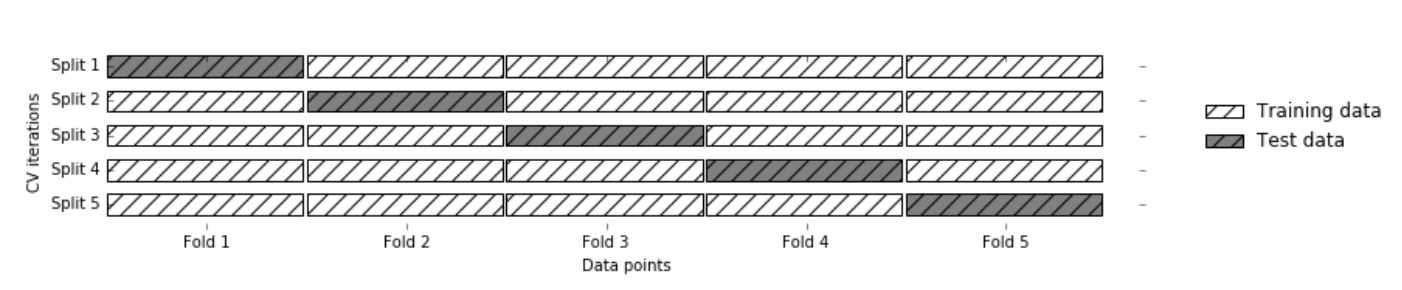



---


**Step 3: Training and Testing**

In [ ]:
# ── Evaluate using 5-fold cross-validation ────────────────────────────────
# Cross-validation splits the data into 5 folds.
# Each fold is used as the test set once, with the other 4 used for training.
# The final score is the average across all 5 folds.
#
# StratifiedKFold ensures each fold has the same class ratio as the full dataset
# — important when classes are imbalanced (37% malignant, 63% benign here)

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_clf = {
    'Elastic Net':    en_clf,
    'Random Forest':  rf_clf,
    'Neural Network': mlp_clf
}

results_clf = {}
print(f"{'Model':<16} {'Accuracy':>10} {'±SD':>7} {'ROC-AUC':>10} {'±SD':>7}")
print('-' * 55)

for name, model in models_clf.items():
    acc  = cross_val_score(model, X_clf, y_clf, cv=cv_clf,
                            scoring='accuracy', n_jobs=-1)
    auc  = cross_val_score(model, X_clf, y_clf, cv=cv_clf,
                            scoring='roc_auc', n_jobs=-1)
    pred = cross_val_predict(model, X_clf, y_clf, cv=cv_clf)
    prob = cross_val_predict(model, X_clf, y_clf, cv=cv_clf,
                              method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y_clf, prob)
    cm = confusion_matrix(y_clf, pred)
    results_clf[name] = {
        'acc': acc, 'auc': auc, 'cm': cm, 'fpr': fpr, 'tpr': tpr
    }
    print(f"{name:<16} {acc.mean()*100:>9.1f}% "
          f"{acc.std()*100:>6.1f}% "
          f"{auc.mean():>10.3f} {auc.std():>6.3f}")

**We've already started to evaluate the models with the accuracy score, which is the ratio of correct predictions to total predictions. We can get more insight using other performance metrics.**

# Key Concept #4: Performance Evaluation

Validation is an essential step in machine learning. Two important goals when tuning an algorithm are:
- To prevent excessive **bias**, in which the model *underfits* the data (too simple to capture real patterns)
- To prevent excessive **variance**, in which the model *overfits* the data (so complex that it learns the noise in the training data rather than underlying patterns)

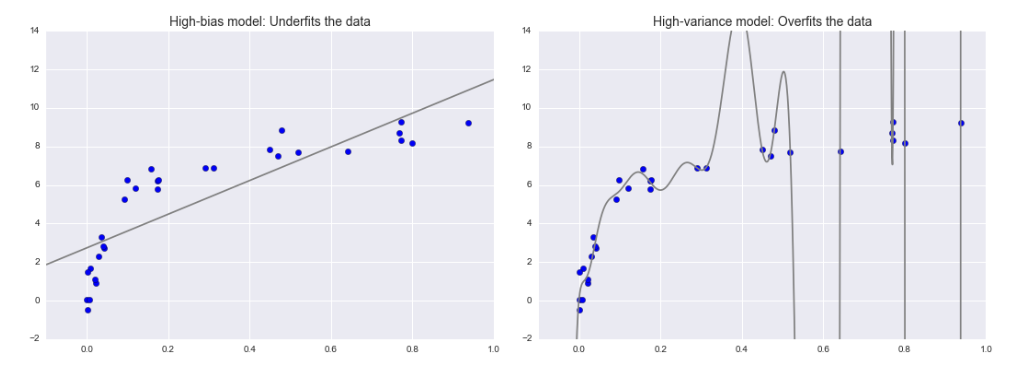


A simple metric to evaluate the performance of a machine learning algorithm is the **accuracy score**, which is defined as follows:

$$\text{Accuracy} = \frac{\text{correct predictions}}{\text{total predictions}}$$

However, imagine a scenario in which 90% of the tumors are benign and 10% are malignant. This is an example of **class imbalance**, and it can skew the evaluation of the model. A model that always predicts "benign" would achieve 90% accuracy without learning anything meaningful about the data.

Alternative performance metrics provide more insight into how well the model is actually discriminating between classes. The two we will use for classification tasks are **confusion matrices** and **receiver operating characteristic (ROC) curves**, which together summarize where the model succeeds and where it fails.

An **ROC curve** is a plot that visualizes the tradeoff between a model's ability to correctly identify positive cases (sensitivity) and its tendency to incorrectly flag negative cases as positive (false positive rate) across all possible classification thresholds. A model with no
predictive ability produces a diagonal line, while a perfect model hugs the top-left corner. The **area under the ROC curve (ROC-AUC)** summarizes this performance in a
single number between 0.5 (no better than random) and 1.0 (perfect).

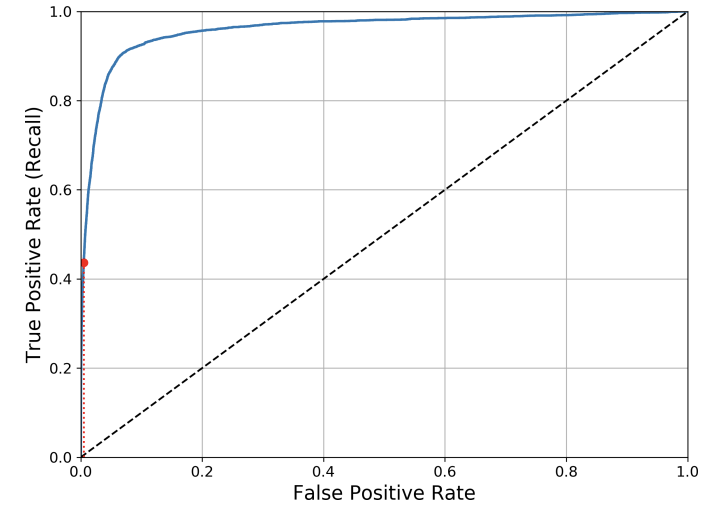

A **confusion matrix** visually depicts the classification results of a model by showing how many samples were correctly and incorrectly classified in each category. Below is the template for a confusion matrix for a binary classification problem.

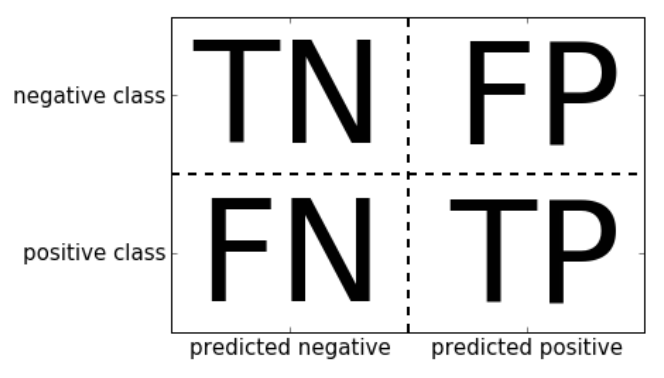

**Now, let's use ROC curves and confusion matrices to further evaluate our models.**



---


**Step 4: Calculate Performance Metrics**


In [ ]:
# ── ROC curves and confusion matrices ─────────────────────────────────────
colors_clf = {
    'Elastic Net':    '#ff9f43',
    'Random Forest':  '#00e5ff',
    'Neural Network': '#7b5cf0'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Classification Results — Breast Cancer Wisconsin',
             fontsize=13, fontweight='bold')

for i, (name, res) in enumerate(results_clf.items()):
    # ROC curve
    ax = axes[0][i]
    ax.plot(res['fpr'], res['tpr'], color=colors_clf[name],
            lw=2.5, label=f"AUC = {res['auc'].mean():.3f}")
    ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Random')
    ax.fill_between(res['fpr'], res['tpr'], alpha=0.08, color=colors_clf[name])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    # Confusion matrix
    ax2 = axes[1][i]
    cm = res['cm']
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
                xticklabels=class_names, yticklabels=class_names,
                cbar=False, annot_kws={'size': 16, 'weight': 'bold'})
    ax2.set_title(
        f'{name}\nAccuracy={res["acc"].mean()*100:.1f}%  '
        f'Missed cancers={fp}',
        fontsize=10, fontweight='bold'
    )
    ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

print('Confusion matrix reminder:')
print('  Rows = Actual class,  Columns = Predicted class')
print('  Numbers in each cell sum to 569 total samples')


---
### 🔧 TRY THIS — How does the number of trees affect Random Forest?

Change `n_estimators` below and re-run. Try values like 1, 10, 50, 200, 500.




---

**Step 5: Model Tuning**

In [ ]:
# 🔧 TRY THIS ─────────────────────────────────────────────────────────────
# Change n_estimators and re-run this cell to see how it affects accuracy.

# >>> CHANGE THIS <<<
n_estimators = 100

import time
rf_test = RandomForestClassifier(
    n_estimators=n_estimators,
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
acc_test = cross_val_score(rf_test, X_clf, y_clf,
                            cv=cv_clf, scoring='accuracy', n_jobs=-1)
elapsed = time.time() - start

print(f'n_estimators = {n_estimators}')
print(f'  Accuracy:   {acc_test.mean()*100:.1f}% ± {acc_test.std()*100:.1f}%')
print(f'  Time:       {elapsed:.1f} seconds')
print()
print('Try: 1, 10, 50, 200, 500')
print('What is the tradeoff between accuracy and computation time?'  )

---
### Why Cross-Validation? The Problem with a Single Train/Test Split

Before moving to regression, let's see concretely why cross-validation
gives more reliable estimates than a single split.

The cell below runs the Neural Network on two specific 80:20 splits of the
breast cancer data — same model, same data, just different random splits.
The results are guaranteed to be different for every student since the seeds
are fixed — the point is the *size* of the difference.

**Note on random_state**

If you and your friend both set `random_state=48` on your own machines, you will get the exact same result. This can help with reproducibility if you want to compare results. If you want a truly randomized split each time, set `random_state=None`.


In [ ]:
# ── Single split vs. cross-validation ────────────────────────────────────
# These two seeds were chosen specifically because they produce very
# different results — demonstrating how much a single split can vary.

cv_acc = results_clf['Neural Network']['acc'].mean()
print(f'Cross-validated accuracy (5-fold CV): {cv_acc*100:.1f}%  ← stable estimate')
print()

# Seed 48: an unlucky split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=48, stratify=y_clf
)
mlp_clf.fit(X_tr, y_tr)
acc_48 = accuracy_score(y_te, mlp_clf.predict(X_te))
print(f'Single split (seed=48,  "unlucky"):  {acc_48*100:.1f}%  '
      f'({(acc_48 - cv_acc)*100:+.1f}pp vs CV)')

# Seed 159: a lucky split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=159, stratify=y_clf
)
mlp_clf.fit(X_tr, y_tr)
acc_159 = accuracy_score(y_te, mlp_clf.predict(X_te))
print(f'Single split (seed=159, "lucky"):   {acc_159*100:.1f}%  '
      f'({(acc_159 - cv_acc)*100:+.1f}pp vs CV)')

print()
print(f'Swing: {acc_48*100:.1f}% → {acc_159*100:.1f}%  '
      f'= {(acc_159 - acc_48)*100:.1f} percentage point difference')
print()
print('Same model. Same data. Just different random splits.')
print()
print('This is why cross-validation matters:')
print('  A single split gives you one potentially misleading number.')
print('  CV averages across many splits to give a stable, honest estimate.')

##**Part 1 Summary**
You have now completed most of the key steps of a machine learning problem - you've selected algorithms, performed training and testing (including cross-validation), evaluated performance, and modified the algorithms to tune the results. But what if we wanted to perform a **regression task?**

---
# PART 2: Regression
## Diabetes Dataset

**The task:** Predict a continuous disease progression score (range 25–346)
one year after baseline, from 10 clinical measurements.

**The dataset:**
- 442 samples, 10 features, continuous target
- Built into scikit-learn — no download needed
- For more information, [follow this link](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset).



---


**Why a different dataset than we used for the classification task?**
The breast cancer dataset has a binary classification (benign vs. malignant) as the target variable. The diabetes dataset predicts a continuous variable (disease progression score)



---


In regression, the model predicts a **number** rather than a category.
We evaluate it with **R²** (how much variance is explained)
and **RMSE** (average prediction error in original units).

**R² interpretation:**
- R² = 1.0 → perfect prediction
- R² = 0.0 → model just predicts the mean every time
- R² < 0.0 → worse than predicting the mean

---

### What changes from Part 1?

```
Classification                  Regression
──────────────────────────────  ──────────────────────────────
LogisticRegression(...)         ElasticNetCV(...)
RandomForestClassifier(...)     RandomForestRegressor(...)
MLPClassifier(...)              MLPRegressor(...)

scoring='accuracy'              scoring='r2'
StratifiedKFold                 KFold
confusion matrix / ROC-AUC      predicted vs actual scatter / RMSE
```

Everything else — Pipeline, StandardScaler, cross_val_score — is identical.



---


**Step 1: Load the Data and Explore Dimensions**

In [ ]:
# ── Load data ─────────────────────────────────────────────────────────────
data_reg       = load_diabetes()
X_reg          = data_reg.data
y_reg          = data_reg.target
feat_names_reg = data_reg.feature_names

print(f'Samples:  {X_reg.shape[0]}')
print(f'Features: {X_reg.shape[1]}')
print(f'Feature names: {list(feat_names_reg)}')
print(f'Target range:  {y_reg.min():.0f} – {y_reg.max():.0f}')
print(f'Target mean:   {y_reg.mean():.1f}')



---


**Step 2: Set Up the ML Algorithms** (notice that it's almost identical to before)

In [ ]:
# ── Define the three regression models ────────────────────────────────────

# Elastic Net Regression (pre-written)
# ElasticNetCV automatically finds the best regularization via cross-validation
en_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-3, 2, 50),
        cv=5, max_iter=5000, random_state=42
    ))
])

# Random Forest Regressor
# Same parameters as RandomForestClassifier — one word changes
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_features='sqrt',
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

# Neural Network Regressor
# Same architecture as MLPClassifier — one word changes
mlp_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='adam',
        alpha=0.01,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

print('✅ Three regression models defined.')
print()
print('Compare to Part 1 — what changed:')
print('  RandomForestClassifier → RandomForestRegressor')
print('  MLPClassifier          → MLPRegressor')
print('  (ElasticNetCV replaces LogisticRegression — different API for regression)'  )



---


**Step 3: Training and Testing**

In [ ]:
# ── Evaluate using 5-fold cross-validation ────────────────────────────────
# KFold (not StratifiedKFold) — no classes to stratify by in regression

kf_reg = KFold(n_splits=5, shuffle=True, random_state=42)

models_reg = {
    'Elastic Net':    en_reg,
    'Random Forest':  rf_reg,
    'Neural Network': mlp_reg
}

results_reg = {}
print(f"{'Model':<16} {'CV R²':>8} {'±SD':>7} {'RMSE':>8}")
print('-' * 44)

for name, model in models_reg.items():
    cv_r2  = cross_val_score(model, X_reg, y_reg,
                               cv=kf_reg, scoring='r2', n_jobs=-1)
    y_pred = cross_val_predict(model, X_reg, y_reg, cv=kf_reg)
    rmse   = np.sqrt(mean_squared_error(y_reg, y_pred))
    results_reg[name] = {'cv_r2': cv_r2, 'y_pred': y_pred, 'rmse': rmse}
    print(f"{name:<16} {cv_r2.mean():>8.3f} "
          f"{cv_r2.std():>6.3f} {rmse:>8.1f}")

print()
print(f'Target range: {y_reg.min():.0f}–{y_reg.max():.0f}')
print('RMSE tells you the average prediction error in the original units.')
print('R² ≈ 0.47 means the models explain about 47% of variance.')
print()
print('Is 47% good? It depends on the problem.')




---


**Step 4: Calculate Performance Metrics**

In [ ]:
# ── Predicted vs actual plots ─────────────────────────────────────────────
# The regression equivalent of a confusion matrix.
# Points close to the dashed diagonal = accurate predictions.
# Scatter around the line = prediction error.

colors_reg = {
    'Elastic Net':    '#ff9f43',
    'Random Forest':  '#00e5ff',
    'Neural Network': '#7b5cf0'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Regression Results — Diabetes Dataset\n'
             '(5-fold CV predictions, all 442 patients)',
             fontsize=13, fontweight='bold')

for i, (name, res) in enumerate(results_reg.items()):
    ax   = axes[i]
    r2   = res['cv_r2'].mean()
    rmse = res['rmse']

    ax.scatter(y_reg, res['y_pred'],
               color=colors_reg[name], alpha=0.6,
               edgecolors='white', linewidths=0.4, s=40)

    mn = min(y_reg.min(), res['y_pred'].min()) - 5
    mx = max(y_reg.max(), res['y_pred'].max()) + 5
    ax.plot([mn,mx],[mn,mx],'k--', lw=1.5, alpha=0.5, label='Perfect')

    ax.text(0.04, 0.96,
            f'CV R² = {r2:.3f} ± {res["cv_r2"].std():.3f}\nRMSE = {rmse:.1f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    ax.set_xlabel('Actual Disease Progression', fontsize=10)
    ax.set_ylabel('Predicted', fontsize=10)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
### 🔧 TRY THIS — How does Neural Network architecture affect regression?

Change `hidden_layer_sizes` below and re-run. Try different architectures.

Some options to try:
- `(8,)` — one hidden layer, 8 units
- `(64, 32)` — two hidden layers, 64 then 32 units
- `(128, 64, 32)` — three hidden layers
- `(4,)` — very small network




---


**Step 5: Model Tuning**

In [ ]:
# 🔧 TRY THIS ─────────────────────────────────────────────────────────────
# Change hidden_layer_sizes and re-run.
# This controls how many layers and how many neurons per layer.
# Format: (n1,) = one layer with n1 neurons
#         (n1, n2) = two layers, n1 then n2 neurons

# >>> CHANGE THIS <<<
hidden_layer_sizes = (8,)

mlp_test = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation='relu',
        solver='adam',
        alpha=0.01,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

cv_r2_test = cross_val_score(mlp_test, X_reg, y_reg,
                               cv=kf_reg, scoring='r2', n_jobs=-1)

print(f'hidden_layer_sizes = {hidden_layer_sizes}')
print(f'  CV R²: {cv_r2_test.mean():.3f} ± {cv_r2_test.std():.3f}')
print()


---
## Summary

**Classification vs Regression — what changed:**

| | Classification | Regression |
|-|---------------|-----------|
| Model classes | `...Classifier`, `LogisticRegression` | `...Regressor`, `ElasticNetCV` |
| CV object | `StratifiedKFold` | `KFold` |
| Scoring | `'accuracy'`, `'roc_auc'` | `'r2'` |
| Evaluation plots | Confusion matrix, ROC curve | Predicted vs actual scatter |

**What stayed identical:**
`Pipeline`, `StandardScaler`, `cross_val_score`, `cross_val_predict`, `random_state=42`

**Key takeaways:**

1. An understanding of important concepts in machine learning
- Classification and regression
- Training and testing
- Cross-validation
- Bias and variance
- Performance metrics
2. Practice with three common machine learning algorithms
- Elastic net
- Random forest
- Neural network
3. A demonstration of a basic machine learning workflow
- Model selection
- Training and testing
- Performance evaluation
- Model tuning



**Week 9:** We will apply these concepts to our pan-cancer dataset in class.

---
*BME 2080 · Module 3 · Spring 2026*